## Mean-reversion-based pairs trading strategy

### Data Collection

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

In [2]:
# Fetches S&P 500 tickers from Wikipedia
def get_sp500_tickers():

    url = 'https://en.wikipedia.org/wiki/List_of_S%26P_500_companies'
    tables = pd.read_html(url)
    sp500_table = tables[0]
    tickers = sp500_table['Symbol'].tolist()
    
    # Clean tickers
    tickers = [ticker.replace('.', '-') for ticker in tickers]
    
    print(f"Found {len(tickers)} S&P 500 stocks")
    return tickers

In [3]:
# Downloads historical data
def download_stock_data(tickers, start_date='2022-01-01', end_date='2024-12-31'):

    print(f"Downloading data from {start_date} to {end_date}.")
    
    # Downloads data in batches
    all_data = {}
    failed_tickers = []
    
    for i, ticker in enumerate(tickers):
        try:
            stock = yf.Ticker(ticker)
            hist = stock.history(start=start_date, end=end_date)
            
            if len(hist) > 0:
                all_data[ticker] = hist['Close']  # Adjusted close
            else:
                failed_tickers.append(ticker)
                
        except Exception as e:
            print(f"Failed to download {ticker}: {e}")
            failed_tickers.append(ticker)
        
        # Progress indicator
        if (i + 1) % 50 == 0:
            print(f"Downloaded {i + 1}/{len(tickers)} stocks...")
    
    # Creates DataFrame
    price_data = pd.DataFrame(all_data)
    
    print(f"Successfully downloaded {len(price_data.columns)} stocks")
    print(f"Failed to download {len(failed_tickers)} stocks: {failed_tickers[:10]}...")
    
    return price_data


In [6]:
price_data = pd.read_csv('./sp500_prices_cleaned.csv', index_col=0, parse_dates=True)
price_data = price_data.select_dtypes(include=[np.number])  # Keep only numeric columns

In [7]:
from statsmodels.tsa.stattools import coint, adfuller
import warnings
warnings.filterwarnings('ignore')

def preprocess_for_cointegration(price_data):
    """
    Preprocess price data for cointegration analysis
    Following professor's requirements for log transformation and stationarity checks
    """
    print("=== DATA PREPROCESSING FOR COINTEGRATION ===")
    print(f"Input data shape: {price_data.shape}")
    print(f"Date range: {price_data.index[0]} to {price_data.index[-1]}")
    
    # Step 1: Log transformation (professor's requirement)
    print(f"\n1. Applying log transformation...")
    
    # Ensure all prices are positive before log transformation
    min_prices = price_data.min()
    negative_or_zero = min_prices[min_prices <= 0]
    
    if len(negative_or_zero) > 0:
        print(f"   WARNING: Found {len(negative_or_zero)} stocks with non-positive prices")
        print(f"   Removing stocks: {negative_or_zero.index.tolist()}")
        price_data = price_data.drop(columns=negative_or_zero.index)
    
    # Apply log transformation
    log_prices = np.log(price_data)
    
    # Verify no infinite or NaN values after transformation
    inf_check = log_prices.isin([np.inf, -np.inf]).any()
    nan_check = log_prices.isnull().any()
    
    if inf_check.any():
        print(f"   WARNING: Infinite values found in: {inf_check[inf_check].index.tolist()}")
        log_prices = log_prices.replace([np.inf, -np.inf], np.nan)
        log_prices = log_prices.dropna(axis=1)
    
    print(f"   Log-transformed data shape: {log_prices.shape}")
    print(f"   Successfully processed {log_prices.shape[1]} stocks")
    
    return log_prices

In [8]:
def check_stationarity_sample(log_prices, sample_size=10, significance_level=0.05):
    """
    Check stationarity on a sample of stocks using ADF test
    Based on professor's slides on ADF testing
    """
    print(f"\n2. Stationarity Analysis (ADF Test on {sample_size} stocks)...")
    
    # Sample stocks for testing
    sample_stocks = np.random.choice(log_prices.columns, 
                                   min(sample_size, len(log_prices.columns)), 
                                   replace=False)
    
    stationarity_results = {}
    stationary_count = 0
    
    for stock in sample_stocks:
        try:
            adf_result = adfuller(log_prices[stock].dropna())
            
            is_stationary = adf_result[1] < significance_level
            if is_stationary:
                stationary_count += 1
                
            stationarity_results[stock] = {
                'adf_statistic': adf_result[0],
                'p_value': adf_result[1],
                'critical_values': adf_result[4],
                'is_stationary': is_stationary
            }
            
        except Exception as e:
            print(f"   Error testing {stock}: {e}")
    
    print(f"   Stationarity Test Results:")
    print(f"   Stationary stocks: {stationary_count}/{len(sample_stocks)}")
    
    for stock, result in list(stationarity_results.items())[:5]:  # Show first 5
        print(f"   {stock}: ADF p-value = {result['p_value']:.4f}, "
              f"Stationary = {result['is_stationary']}")
    
    return stationarity_results

In [9]:
log_prices = preprocess_for_cointegration(price_data)
stationarity_results = check_stationarity_sample(log_prices)

=== DATA PREPROCESSING FOR COINTEGRATION ===
Input data shape: (752, 497)
Date range: 2022-01-03 00:00:00-05:00 to 2024-12-30 00:00:00-05:00

1. Applying log transformation...
   Log-transformed data shape: (752, 497)
   Successfully processed 497 stocks

2. Stationarity Analysis (ADF Test on 10 stocks)...
   Stationarity Test Results:
   Stationary stocks: 0/10
   PRU: ADF p-value = 0.6081, Stationary = False
   MLM: ADF p-value = 0.7902, Stationary = False
   K: ADF p-value = 0.8699, Stationary = False
   AVB: ADF p-value = 0.4168, Stationary = False
   FI: ADF p-value = 0.9784, Stationary = False


In [10]:
def clean_data(price_data, min_data_threshold=0.95, min_trading_days=0.8):

    print("  DATA CLEANING  ")
    print(f"Original data shape: {price_data.shape}")
    print(f"Date range: {price_data.index[0]} to {price_data.index[-1]}")
    print(f"Initial missing data points: {price_data.isnull().sum().sum()}")
    
    # Remove stocks with insufficient data
    print(f"\n1. Filtering stocks with <{min_data_threshold*100}% data availability...")
    data_availability = price_data.count() / len(price_data)
    good_stocks = data_availability[data_availability >= min_data_threshold].index
    filtered_data = price_data[good_stocks].copy()
    
    print(f"   Kept {len(good_stocks)} stocks")
    print(f"   Removed {len(price_data.columns) - len(good_stocks)} stocks")
    print(f"   Missing data points after stock filter: {filtered_data.isnull().sum().sum()}")
    
    # Handle missing data with forward fill
    print(f"\n2. Handling missing data...")
    print(f"   Missing data points before fill: {filtered_data.isnull().sum().sum()}")
    
    # Forward fill missing values 
    filtered_data = filtered_data.fillna(method='ffill')
    
    # If there are still missing values at the beginning, backward fill
    if filtered_data.isnull().sum().sum() > 0:
        filtered_data = filtered_data.fillna(method='bfill')
    
    print(f"   Missing data points after fill: {filtered_data.isnull().sum().sum()}")
    
    #  Remove days with too many missing stocks 
    print(f"\n3. Filtering trading days...")
    missing_per_day = filtered_data.isnull().sum(axis=1)
    max_missing_stocks = int(len(filtered_data.columns) * (1 - min_trading_days))
    
    print(f"   Maximum allowed missing stocks per day: {max_missing_stocks}")
    
    # Keep days where we have at least 80% of stocks with data
    valid_days = missing_per_day <= max_missing_stocks
    final_data = filtered_data[valid_days].copy()
    
    removed_days = len(filtered_data) - len(final_data)
    print(f"   Removed {removed_days} days with too many missing stocks")
    print(f"   Missing data points after day filter: {final_data.isnull().sum().sum()}")
    
    # Step 4: Final cleanup 
    completely_empty_rows = final_data.isnull().all(axis=1)
    if completely_empty_rows.any():
        final_data = final_data[~completely_empty_rows]
        print(f"   Removed {completely_empty_rows.sum()} completely empty days")
    
    # Final statistics
    print(f"\n=== FINAL RESULTS ===")
    print(f"Final data shape: {final_data.shape}")
    print(f"Final date range: {final_data.index[0]} to {final_data.index[-1]}")
    print(f"Total missing values: {final_data.isnull().sum().sum()}")
    print(f"Data completeness: {(1 - final_data.isnull().sum().sum() / (final_data.shape[0] * final_data.shape[1])) * 100:.2f}%")
    
    return final_data


# Main execution
if __name__ == "__main__":
    # Get S&P 500 tickers
    sp500_tickers = get_sp500_tickers()
    
    # Download data
    raw_data = download_stock_data(sp500_tickers)
    
    # Clean data
    clean_price_data = clean_data(raw_data)
    
    # Save for later use
    clean_price_data.to_csv('sp500_prices_cleaned.csv')
    print("Data saved to 'sp500_prices_cleaned.csv'")
    
    # Basic statistics
    print(f"\nFinal dataset summary:")
    print(f"Number of stocks: {clean_price_data.shape[1]}")
    print(f"Number of trading days: {clean_price_data.shape[0]}")

Found 503 S&P 500 stocks
Downloaded 50/503 stocks...
Downloaded 100/503 stocks...
Downloaded 150/503 stocks...
Downloaded 200/503 stocks...
Downloaded 250/503 stocks...
Downloaded 300/503 stocks...
Downloaded 350/503 stocks...
Downloaded 400/503 stocks...
Downloaded 450/503 stocks...
Downloaded 500/503 stocks...
Successfully downloaded 503 stocks
Failed to download 0 stocks: []...
  DATA CLEANING  
Original data shape: (752, 503)
Date range: 2022-01-03 00:00:00-05:00 to 2024-12-30 00:00:00-05:00
Initial missing data points: 2779

1. Filtering stocks with <95.0% data availability...
   Kept 497 stocks
   Removed 6 stocks
   Missing data points after stock filter: 11

2. Handling missing data...
   Missing data points before fill: 11
   Missing data points after fill: 0

3. Filtering trading days...
   Maximum allowed missing stocks per day: 99
   Removed 0 days with too many missing stocks
   Missing data points after day filter: 0

=== FINAL RESULTS ===
Final data shape: (752, 497)
Fin

### Data Cleaning

### Finding Cointegrated Pairs

In [11]:
import yfinance as yf
from collections import defaultdict
import time

def get_sectors_automatically(stock_tickers, batch_size=50):
  
    print(f"Classifying {len(stock_tickers)} stocks by sector...")
    
    sectors = defaultdict(list)
    failed_tickers = []
    
    for i, ticker in enumerate(stock_tickers):
        try:
            stock = yf.Ticker(ticker)
            info = stock.info
            
            sector = info.get('sector', 'Unknown')
            industry = info.get('industry', 'Unknown')
            
            # Clean up sector names
            if sector and sector != 'Unknown':
                sectors[sector].append(ticker)
            else:
                sectors['Unknown'].append(ticker)
            
            # Progress indicator
            if (i + 1) % batch_size == 0:
                print(f"Processed {i + 1}/{len(stock_tickers)} stocks...")
                
            # Rate limiting to avoid API limits
            time.sleep(0.1)
            
        except Exception as e:
            print(f"Failed to get sector for {ticker}: {e}")
            failed_tickers.append(ticker)
            sectors['Unknown'].append(ticker)
    
    # Convert to regular dict and show results
    sectors_dict = dict(sectors)
    
    print(f"\n=== SECTOR CLASSIFICATION RESULTS ===")
    for sector, stocks in sectors_dict.items():
        print(f"{sector}: {len(stocks)} stocks")
        if len(stocks) <= 10:  # Show stocks for smaller sectors
            print(f"  Stocks: {stocks}")
    
    print(f"\nFailed to classify: {len(failed_tickers)} stocks")
    
    return sectors_dict, failed_tickers

In [12]:
# Extract stock tickers from your price_data DataFrame
stock_tickers = price_data.columns.tolist()

In [13]:
# Then run the sector classification
sectors_dict, failed_tickers = get_sectors_automatically(stock_tickers)

Classifying 497 stocks by sector...
Processed 50/497 stocks...
Processed 100/497 stocks...
Processed 150/497 stocks...
Processed 200/497 stocks...
Processed 250/497 stocks...
Processed 300/497 stocks...
Processed 350/497 stocks...
Processed 400/497 stocks...
Processed 450/497 stocks...

=== SECTOR CLASSIFICATION RESULTS ===
Industrials: 69 stocks
Healthcare: 59 stocks
Technology: 82 stocks
Utilities: 31 stocks
Financial Services: 68 stocks
Basic Materials: 20 stocks
Consumer Cyclical: 55 stocks
Real Estate: 31 stocks
Communication Services: 23 stocks
Consumer Defensive: 36 stocks
Energy: 23 stocks

Failed to classify: 0 stocks


In [46]:
from statsmodels.tsa.stattools import coint
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from itertools import combinations
import warnings
warnings.filterwarnings('ignore')

def filter_ab_stocks(stock_list):
    """
    Remove A/B class stock pairs to avoid trivial correlations
    Based on actual analysis of S&P 500 dataset
    """
    filtered_stocks = []
    excluded_pairs = []
    
    # ACTUAL A/B patterns present in the S&P 500 dataset (verified by data analysis)
    ab_patterns = [
        ('GOOGL', 'GOOG'),  # Google Class A vs Class C - keep GOOG (more liquid)
        ('FOXA', 'FOX'),    # Fox Class A vs Class B - keep FOX (more liquid) 
        ('NWSA', 'NWS')     # News Corp Class A vs Class B - keep NWS (more liquid)
    ]
    
    # Create exclusion set
    exclude_stocks = set()
    for stock_a, stock_b in ab_patterns:
        if stock_a in stock_list and stock_b in stock_list:
            # Keep the more liquid share class (typically the one without 'A' suffix)
            if stock_a.endswith('A'):
                exclude_stocks.add(stock_a)  # Remove A shares, keep regular shares
                excluded_pairs.append((stock_a, stock_b))
            else:
                exclude_stocks.add(stock_b)
                excluded_pairs.append((stock_a, stock_b))
    
    # Filter out excluded stocks
    filtered_stocks = [stock for stock in stock_list if stock not in exclude_stocks]
    
    if excluded_pairs:
        print(f"    Excluded A/B class pairs: {excluded_pairs}")
        print(f"    Removed {len(exclude_stocks)} stocks: {list(exclude_stocks)}")
        print(f"    Kept {len(filtered_stocks)} stocks for pair testing")
    else:
        print(f"    No A/B class pairs found in this sector")
        filtered_stocks = stock_list
    
    return filtered_stocks

In [47]:
def test_cointegration_pairs(log_prices, sectors_dict, max_pairs_per_sector=15, p_threshold=0.05):

    
    print("\n=== COINTEGRATION TESTING (ENGLE-GRANGER METHOD) ===")
    
    # Filter sectors suitable for pairs trading (need sufficient stocks)
    print("\n=== FILTERING SECTORS FOR PAIR TESTING ===")
    min_stocks_per_sector = 5  # Need at least 5 stocks to form meaningful pairs
    
    suitable_sectors = {sector: stocks for sector, stocks in sectors_dict.items() 
                       if len(stocks) >= min_stocks_per_sector}
    
    print("Sectors suitable for pairs trading:")
    for sector, stocks in suitable_sectors.items():
        print(f"  {sector}: {len(stocks)} stocks")
    
    all_results = []
    total_pairs_tested = 0
    
    # Test pairs within each sector
    for sector, sector_stocks in suitable_sectors.items():
        print(f"\nTesting {sector} sector ({len(sector_stocks)} stocks)...")
        
        # Filter out A/B class stocks
        filtered_stocks = filter_ab_stocks(sector_stocks)
        
        # Only test stocks that exist in our price data
        available_stocks = [stock for stock in filtered_stocks if stock in log_prices.columns]
        
        if len(available_stocks) < 2:
            print(f"  Insufficient stocks available for {sector}, skipping...")
            continue
            
        # Generate pairs for testing
        possible_pairs = list(combinations(available_stocks, 2))
        
        # Limit pairs per sector for computational efficiency
        if len(possible_pairs) > max_pairs_per_sector:
            # Randomly sample pairs or use some other strategy
            np.random.seed(42)  # For reproducibility
            test_pairs = np.random.choice(len(possible_pairs), max_pairs_per_sector, replace=False)
            pairs_to_test = [possible_pairs[i] for i in test_pairs]
        else:
            pairs_to_test = possible_pairs
        
        sector_results = []
        
        # Test each pair using Engle-Granger method
        for stock1, stock2 in pairs_to_test:
            try:
                # Get aligned price series
                series1 = log_prices[stock1].dropna()
                series2 = log_prices[stock2].dropna()
                
                # Find common trading days
                common_dates = series1.index.intersection(series2.index)
                
                # Require minimum data points (at least 1 year)
                min_observations = 252
                if len(common_dates) < min_observations:
                    continue
                    
                aligned_s1 = series1[common_dates]
                aligned_s2 = series2[common_dates]
                
                # Apply Engle-Granger cointegration test (professor's requirement)
                coint_stat, p_value, critical_values = coint(aligned_s1, aligned_s2)
                
                # Store results
                result = {
                    'Stock1': stock1,
                    'Stock2': stock2,
                    'Sector': sector,
                    'Cointegration_Statistic': coint_stat,
                    'P_Value': p_value,
                    'Critical_1%': critical_values[0],
                    'Critical_5%': critical_values[1], 
                    'Critical_10%': critical_values[2],
                    'Is_Cointegrated': p_value < p_threshold,
                    'Observations': len(common_dates),
                    'Pair_Name': f"{stock1}~{stock2}"
                }
                
                sector_results.append(result)
                total_pairs_tested += 1
                
            except Exception as e:
                print(f"  Error testing {stock1}-{stock2}: {str(e)}")
                continue
        
        print(f"  Completed {len(sector_results)} pair tests")
        all_results.extend(sector_results)
    
    print(f"\n=== TESTING COMPLETE ===")
    print(f"Total pairs tested: {total_pairs_tested}")
    print(f"Total results found: {len(all_results)}")
    
    return pd.DataFrame(all_results)

In [48]:
def analyze_cointegration_results(results_df, p_threshold=0.05, max_pairs_per_stock=2):
    """
    Analyze cointegration results and create diversified top 10 list
    
    Parameters:
    -----------
    results_df : pd.DataFrame
        Results from cointegration testing
    p_threshold : float
        P-value threshold for significance
    max_pairs_per_stock : int
        Maximum number of pairs any single stock can appear in top 10
    """
    
    print(f"\n=== COINTEGRATION ANALYSIS RESULTS ===")
    print(f"Total pairs tested: {len(results_df)}")
    
    # Filter significant pairs (professor's requirement: p < 0.05)
    significant_pairs = results_df[results_df['P_Value'] < p_threshold].copy()
    print(f"Significant pairs (p < {p_threshold}): {len(significant_pairs)}")
    
    if len(significant_pairs) == 0:
        print("No significant cointegrated pairs found!")
        return pd.DataFrame()
    
    # Sort by p-value (most significant first)
    significant_pairs = significant_pairs.sort_values('P_Value').reset_index(drop=True)
    
    # Create diversified top 10 (avoid stock domination)
    diversified_top_10 = []
    stock_count = {}
    
    for idx, row in significant_pairs.iterrows():
        stock1, stock2 = row['Stock1'], row['Stock2']
        
        # Check if either stock already appears too many times
        current_count_1 = stock_count.get(stock1, 0)
        current_count_2 = stock_count.get(stock2, 0)
        
        if (current_count_1 < max_pairs_per_stock and 
            current_count_2 < max_pairs_per_stock and 
            len(diversified_top_10) < 10):
            
            diversified_top_10.append(row)
            stock_count[stock1] = current_count_1 + 1
            stock_count[stock2] = current_count_2 + 1
    
    top_10_df = pd.DataFrame(diversified_top_10)
    
    print(f"\n=== TOP 10 COINTEGRATED PAIRS ===")
    print("Rank Pair            P-Value    Sector")
    print("-" * 50)
    
    for i, row in top_10_df.iterrows():
        rank = i + 1
        pair_name = f"{row['Stock1']}~{row['Stock2']}"
        p_val = row['P_Value']
        sector = row['Sector']
        print(f"{rank:<4} {pair_name:<15} {p_val:.4f}     {sector}")
    
    return top_10_df

In [49]:
def create_cointegration_heatmap(results_df, top_n_stocks=20):
    """
    Create heatmap of p-values for top stocks (professor's optional requirement)
    """
    print(f"\n=== CREATING P-VALUE HEATMAP ===")
    
    if len(results_df) == 0:
        print("No results available for heatmap")
        return
        
    # Get most frequently tested stocks
    all_stocks = pd.concat([results_df['Stock1'], results_df['Stock2']])
    stock_frequencies = all_stocks.value_counts()
    
    if len(stock_frequencies) < 10:
        print("Insufficient pair data for heatmap")
        return
        
    top_stocks = stock_frequencies.head(top_n_stocks).index.tolist()
    
    # Create p-value matrix
    n_stocks = len(top_stocks)
    p_value_matrix = np.ones((n_stocks, n_stocks))  # Initialize with 1.0 (no significance)
    
    # Fill matrix with p-values
    for _, row in results_df.iterrows():
        stock1, stock2 = row['Stock1'], row['Stock2']
        if stock1 in top_stocks and stock2 in top_stocks:
            i = top_stocks.index(stock1)
            j = top_stocks.index(stock2)
            p_val = row['P_Value']
            p_value_matrix[i, j] = p_val
            p_value_matrix[j, i] = p_val  # Symmetric matrix
    
    # Create heatmap using seaborn (professor's specification)
    plt.figure(figsize=(14, 12))
    mask = p_value_matrix == 1.0  # Mask untested pairs
    
    sns.heatmap(p_value_matrix, 
                xticklabels=top_stocks,
                yticklabels=top_stocks,
                annot=True,
                fmt='.3f',
                cmap='RdYlBu_r',
                vmin=0, 
                vmax=0.1,  # Focus on significant range
                mask=mask,
                cbar_kws={'label': 'P-Value'})
    
    plt.title('Cointegration P-Values Heatmap\n(Lower values indicate stronger cointegration)', 
              fontsize=14, fontweight='bold')
    plt.xlabel('Stock Ticker', fontsize=12)
    plt.ylabel('Stock Ticker', fontsize=12)
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()
    
    print(f"Heatmap created for top {len(top_stocks)} most frequently tested stocks")


In [50]:
def run_complete_cointegration_analysis(log_prices, sectors_dict):
    """
    Execute complete cointegration analysis following professor's requirements
    """
    print("Starting comprehensive cointegration analysis...")
    
    # Step 1: Test cointegration using Engle-Granger method
    cointegration_results = test_cointegration_pairs(log_prices, sectors_dict)
    
    # Step 2: Analyze results and create diversified top 10
    top_10_pairs = analyze_cointegration_results(cointegration_results)
    
    # Step 3: Create optional heatmap (professor's suggestion)
    create_cointegration_heatmap(cointegration_results)
    
    # Step 4: Save results for next project phases
    cointegration_results.to_csv('cointegration_results.csv', index=False)
    if len(top_10_pairs) > 0:
        top_10_pairs.to_csv('top_10_cointegrated_pairs.csv', index=False)
        
        # Display summary statistics
        print(f"\n=== SUMMARY STATISTICS ===")
        print(f"Mean p-value of top 10: {top_10_pairs['P_Value'].mean():.4f}")
        print(f"Median p-value of top 10: {top_10_pairs['P_Value'].median():.4f}")
        print(f"Sectors represented in top 10:")
        sector_counts = top_10_pairs['Sector'].value_counts()
        for sector, count in sector_counts.items():
            print(f"  {sector}: {count} pairs")
    
    return cointegration_results, top_10_pairs


Starting comprehensive cointegration analysis...

=== COINTEGRATION TESTING (ENGLE-GRANGER METHOD) ===

=== FILTERING SECTORS FOR PAIR TESTING ===
Sectors suitable for pairs trading:
  Industrials: 69 stocks
  Healthcare: 59 stocks
  Technology: 82 stocks
  Utilities: 31 stocks
  Financial Services: 68 stocks
  Basic Materials: 20 stocks
  Consumer Cyclical: 55 stocks
  Real Estate: 31 stocks
  Communication Services: 23 stocks
  Consumer Defensive: 36 stocks
  Energy: 23 stocks

Testing Industrials sector (69 stocks)...
    No A/B class pairs found in this sector
  Completed 15 pair tests

Testing Healthcare sector (59 stocks)...
    No A/B class pairs found in this sector
  Completed 15 pair tests

Testing Technology sector (82 stocks)...
    No A/B class pairs found in this sector
  Completed 15 pair tests

Testing Utilities sector (31 stocks)...
    No A/B class pairs found in this sector
  Completed 15 pair tests

Testing Financial Services sector (68 stocks)...
    No A/B class p

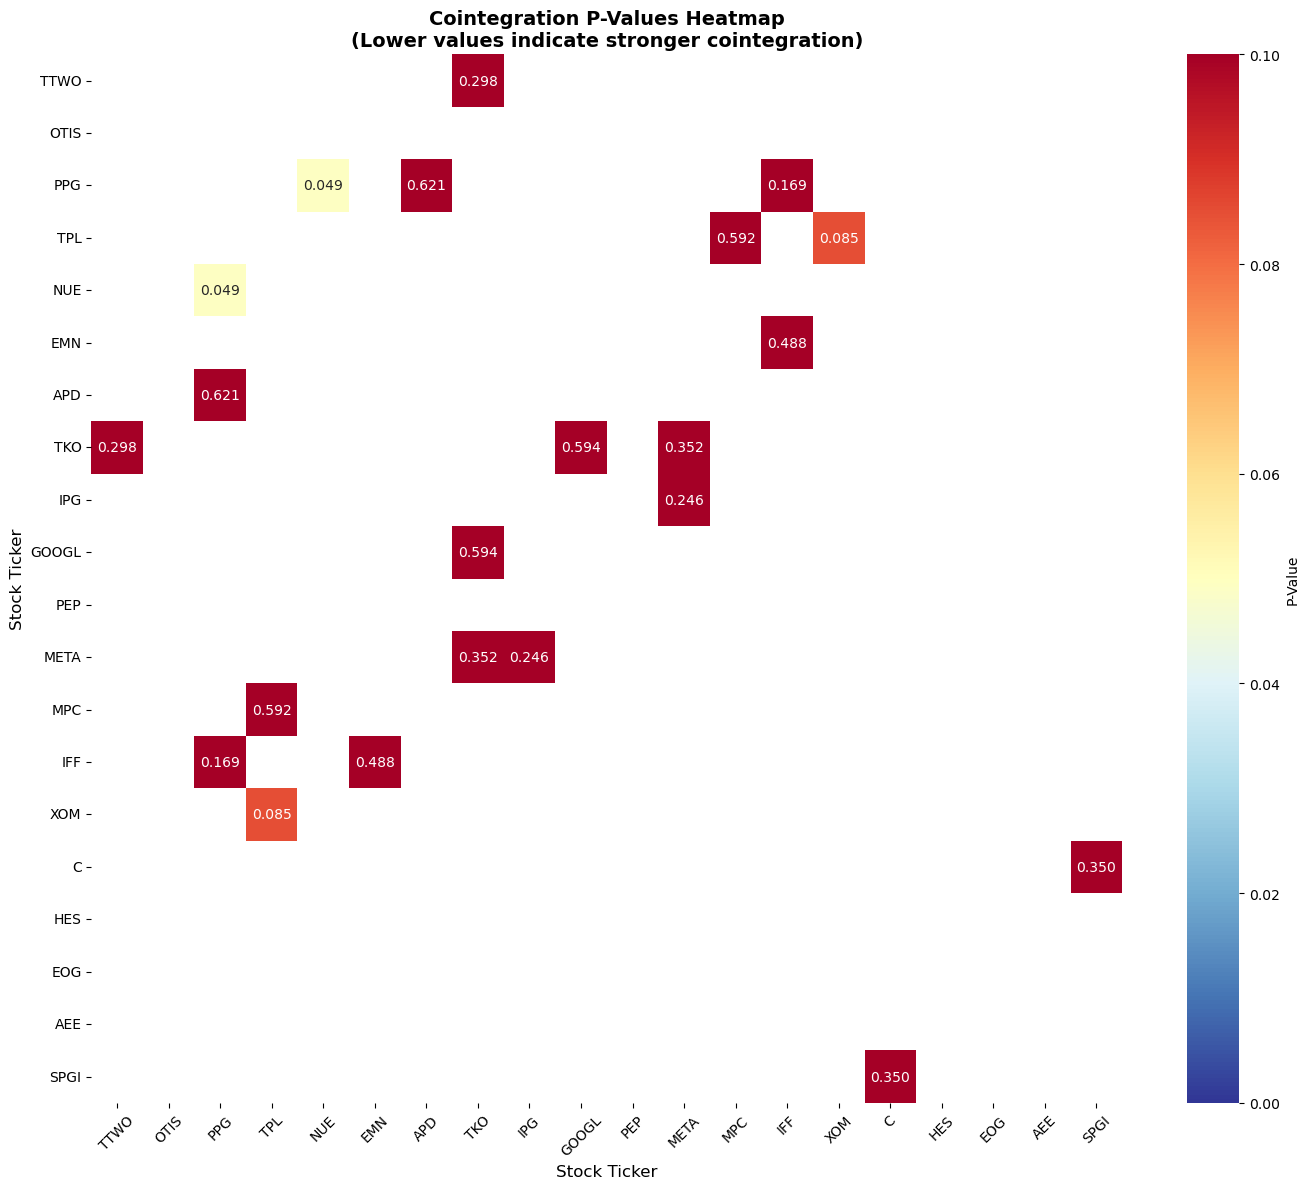

Heatmap created for top 20 most frequently tested stocks

=== SUMMARY STATISTICS ===
Mean p-value of top 10: 0.0167
Median p-value of top 10: 0.0125
Sectors represented in top 10:
  Financial Services: 3 pairs
  Healthcare: 2 pairs
  Technology: 1 pairs
  Consumer Defensive: 1 pairs
  Energy: 1 pairs
  Real Estate: 1 pairs
  Communication Services: 1 pairs


In [51]:
# Execute the analysis
cointegration_results, final_top_10 = run_complete_cointegration_analysis(log_prices, sectors_dict)